<a href="https://colab.research.google.com/github/Kavia-M/Data_science_course-Intellipaat/blob/main/Python/Assignments/Assignment_Quiz/Logistic_Regression_Assignment_Quiz.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Census-income data plays the most important role in the democratic system of government, highly affecting the economic sectors. Census-related figures are used to allocate federal funding by the government to different states and localities.

Census data is also used for post census residents estimates and predictions, economic and social science research, and many other such applications. Therefore, the importance of this data and its accurate predictions is very clear to us. The main aim is to increase awareness about how the income factor actually has an impact not only on the individual lives of citizens but also an effect on the nation and its betterment. You will have a look at the data pulled out from the 1994 Census bureau database, and try to find insights into how various features have an effect on the income of an individual.

The data contains approximately 32,000 observations with over 15 variables.

The strategy is to analyze the data and perform a predictive task of classification to predict whether an individual makes over 50K a year or less by using a logistic regression algorithm.

Column Names	Description

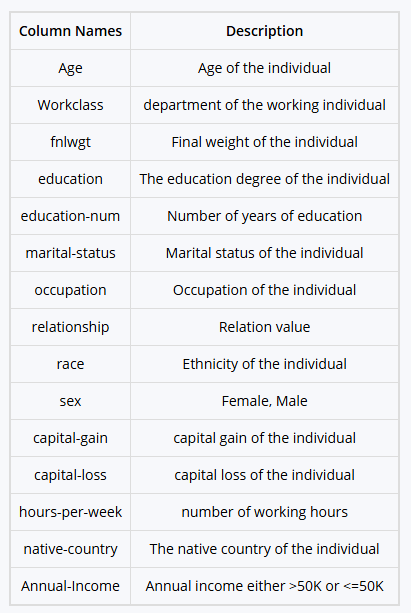

| Column Names     | Description                                          |
|------------------|-----------------------------------------------------|
| Age              | Age of the individual                               |
| Workclass        | department of the working individual                |
| fnlwgt           | Final weight of the individual                      |
| education        | The education degree of the individual              |
| education-num    | Number of years of education                        |
| marital-status   | Marital status of the individual                    |
| occupation       | Occupation of the individual                        |
| relationship     | Relation value                                      |
| race             | Ethnicity of the individual                         |
| sex              | Female, Male                                        |
| capital-gain     | capital gain of the individual                      |
| capital-loss     | capital loss of the individual                      |
| hours-per-week   | number of working hours                             |
| native-country   | The native country of the individual                |
| Annual-Income    | Annual income either >50K or <=50K                  |


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv('/content/census-income .csv')

In [ ]:
df

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,annual_income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32556,27,Private,257302,Assoc-acdm,12,Married-civ-spouse,Tech-support,Wife,White,Female,0,0,38,United-States,<=50K
32557,40,Private,154374,HS-grad,9,Married-civ-spouse,Machine-op-inspct,Husband,White,Male,0,0,40,United-States,>50K
32558,58,Private,151910,HS-grad,9,Widowed,Adm-clerical,Unmarried,White,Female,0,0,40,United-States,<=50K
32559,22,Private,201490,HS-grad,9,Never-married,Adm-clerical,Own-child,White,Male,0,0,20,United-States,<=50K


1) How many types of occupations do we have? (Note: The give dataset contains missing values "?", Thus impute missing values with NaN and perform all the questions accordingly)
- 15
- 11
- 13
- 14

In [ ]:
df['occupation'].value_counts()

,count
occupation,
Prof-specialty,4140
Craft-repair,4099
Exec-managerial,4066
Adm-clerical,3770
Sales,3650
Other-service,3295
Machine-op-inspct,2002
?,1843
Transport-moving,1597


In [ ]:
df['occupation'].nunique()

15

In [ ]:
(df == '?').sum()

,0
age,0
workclass,1836
fnlwgt,0
education,0
education-num,0
marital-status,0
occupation,1843
relationship,0
race,0
sex,0


In [ ]:
df.replace("?", np.nan, inplace=True)

In [ ]:
(df == '?').sum()

,0
age,0
workclass,0
fnlwgt,0
education,0
education-num,0
marital-status,0
occupation,0
relationship,0
race,0
sex,0


In [ ]:
df.isnull().sum()

,0
age,0
workclass,1836
fnlwgt,0
education,0
education-num,0
marital-status,0
occupation,1843
relationship,0
race,0
sex,0


In [ ]:
df.isnull().sum().sum()

np.int64(4262)

In [ ]:
df['occupation'].nunique()

14

1. Answer - 14

2) How many people are working as tech support and have an annual income greater than 50k?
- 934
- 289
- 278
- 389

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             32561 non-null  int64 
 1   workclass       30725 non-null  object
 2   fnlwgt          32561 non-null  int64 
 3   education       32561 non-null  object
 4   education-num   32561 non-null  int64 
 5   marital-status  32561 non-null  object
 6   occupation      30718 non-null  object
 7   relationship    32561 non-null  object
 8   race            32561 non-null  object
 9   sex             32561 non-null  object
 10  capital-gain    32561 non-null  int64 
 11  capital-loss    32561 non-null  int64 
 12  hours-per-week  32561 non-null  int64 
 13  native-country  31978 non-null  object
 14  annual_income   32561 non-null  object
dtypes: int64(6), object(9)
memory usage: 3.7+ MB


In [ ]:
df['annual_income'].value_counts()

,count
annual_income,
<=50K,24720
>50K,7841


In [ ]:
df['workclass'].value_counts()

,count
workclass,
Private,22696
Self-emp-not-inc,2541
Local-gov,2093
State-gov,1298
Self-emp-inc,1116
Federal-gov,960
Without-pay,14
Never-worked,7


In [ ]:
df['occupation'].value_counts()

,count
occupation,
Prof-specialty,4140
Craft-repair,4099
Exec-managerial,4066
Adm-clerical,3770
Sales,3650
Other-service,3295
Machine-op-inspct,2002
Transport-moving,1597
Handlers-cleaners,1370


In [ ]:
df.loc[(df['occupation'] == 'Tech-support') & (df['annual_income'] == '>50K')]

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,annual_income
25,56,Local-gov,216851,Bachelors,13,Married-civ-spouse,Tech-support,Husband,White,Male,0,0,40,United-States,>50K
55,43,Private,237993,Some-college,10,Married-civ-spouse,Tech-support,Husband,White,Male,0,0,40,United-States,>50K
248,40,Private,207578,Assoc-acdm,12,Married-civ-spouse,Tech-support,Husband,White,Male,0,1977,60,United-States,>50K
357,40,Private,96129,Assoc-voc,11,Married-civ-spouse,Tech-support,Husband,White,Male,0,0,40,United-States,>50K
469,30,Private,118551,Bachelors,13,Married-civ-spouse,Tech-support,Wife,White,Female,0,0,16,United-States,>50K
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
31510,42,Private,111483,Bachelors,13,Married-civ-spouse,Tech-support,Husband,White,Male,0,0,50,United-States,>50K
31653,25,Private,189656,Bachelors,13,Never-married,Tech-support,Not-in-family,White,Male,0,0,60,United-States,>50K
31807,51,Self-emp-not-inc,170086,Bachelors,13,Married-civ-spouse,Tech-support,Husband,White,Male,0,0,45,United-States,>50K
32076,59,Federal-gov,293971,Some-college,10,Married-civ-spouse,Tech-support,Husband,White,Male,0,0,40,United-States,>50K


In [ ]:
df_1 = df.dropna()

In [ ]:
df.duplicated().sum()

np.int64(24)

In [ ]:
df_1.duplicated().sum()

np.int64(23)

In [ ]:
df_1.drop_duplicates(inplace=True)

/tmp/ipython-input-2215197706.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_1.drop_duplicates(inplace=True)


In [ ]:
df_1.loc[(df_1['occupation'] == 'Tech-support') & (df_1['annual_income'] == '>50K')]

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,annual_income
25,56,Local-gov,216851,Bachelors,13,Married-civ-spouse,Tech-support,Husband,White,Male,0,0,40,United-States,>50K
55,43,Private,237993,Some-college,10,Married-civ-spouse,Tech-support,Husband,White,Male,0,0,40,United-States,>50K
248,40,Private,207578,Assoc-acdm,12,Married-civ-spouse,Tech-support,Husband,White,Male,0,1977,60,United-States,>50K
357,40,Private,96129,Assoc-voc,11,Married-civ-spouse,Tech-support,Husband,White,Male,0,0,40,United-States,>50K
469,30,Private,118551,Bachelors,13,Married-civ-spouse,Tech-support,Wife,White,Female,0,0,16,United-States,>50K
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
31510,42,Private,111483,Bachelors,13,Married-civ-spouse,Tech-support,Husband,White,Male,0,0,50,United-States,>50K
31653,25,Private,189656,Bachelors,13,Never-married,Tech-support,Not-in-family,White,Male,0,0,60,United-States,>50K
31807,51,Self-emp-not-inc,170086,Bachelors,13,Married-civ-spouse,Tech-support,Husband,White,Male,0,0,45,United-States,>50K
32076,59,Federal-gov,293971,Some-college,10,Married-civ-spouse,Tech-support,Husband,White,Male,0,0,40,United-States,>50K


In [ ]:
len(df_1.loc[(df_1['occupation'] == 'Tech-support') & (df_1['annual_income'] == '>50K')])

278

2. Answer - 278

3) How many total missing values are present in the dataset?
- 4302
- 4262
- 5349
- 5000

In [ ]:
df.isnull().sum().sum()

np.int64(4262)

3. Answer - 4262

4) If there are missing values in the Marital Status column, which option among the following should be used for replacing the missing values:
- Mean
- Median
- All of the above
- Mode

In [ ]:
df.isnull().sum()

,0
age,0
workclass,1836
fnlwgt,0
education,0
education-num,0
marital-status,0
occupation,1843
relationship,0
race,0
sex,0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             32561 non-null  int64 
 1   workclass       30725 non-null  object
 2   fnlwgt          32561 non-null  int64 
 3   education       32561 non-null  object
 4   education-num   32561 non-null  int64 
 5   marital-status  32561 non-null  object
 6   occupation      30718 non-null  object
 7   relationship    32561 non-null  object
 8   race            32561 non-null  object
 9   sex             32561 non-null  object
 10  capital-gain    32561 non-null  int64 
 11  capital-loss    32561 non-null  int64 
 12  hours-per-week  32561 non-null  int64 
 13  native-country  31978 non-null  object
 14  annual_income   32561 non-null  object
dtypes: int64(6), object(9)
memory usage: 3.7+ MB


In [ ]:
#  marital-status  32561 non-null  object

In [ ]:
df['marital-status'].unique()

array(['Never-married', 'Married-civ-spouse', 'Divorced',
       'Married-spouse-absent', 'Separated', 'Married-AF-spouse',
       'Widowed'], dtype=object)

It is object categorical column, so we need to use mode

4. Answer - Mode

5)  How many people are having private work classes and are not from the United States of America?
- 2151
- 2300
- 2190
- 2000

In [ ]:
df['workclass'].unique()

array(['State-gov', 'Self-emp-not-inc', 'Private', 'Federal-gov',
       'Local-gov', nan, 'Self-emp-inc', 'Without-pay', 'Never-worked'],
      dtype=object)

In [ ]:
df['native-country'].unique()

array(['United-States', 'Cuba', 'Jamaica', 'India', nan, 'Mexico',
       'South', 'Puerto-Rico', 'Honduras', 'England', 'Canada', 'Germany',
       'Iran', 'Philippines', 'Italy', 'Poland', 'Columbia', 'Cambodia',
       'Thailand', 'Ecuador', 'Laos', 'Taiwan', 'Haiti', 'Portugal',
       'Dominican-Republic', 'El-Salvador', 'France', 'Guatemala',
       'China', 'Japan', 'Yugoslavia', 'Peru',
       'Outlying-US(Guam-USVI-etc)', 'Scotland', 'Trinadad&Tobago',
       'Greece', 'Nicaragua', 'Vietnam', 'Hong', 'Ireland', 'Hungary',
       'Holand-Netherlands'], dtype=object)

In [ ]:
df['native-country'].nunique()

41

In [ ]:
df['native-country'].value_counts()

,count
native-country,
United-States,29170
Mexico,643
Philippines,198
Germany,137
Canada,121
Puerto-Rico,114
El-Salvador,106
India,100
Cuba,95


In [ ]:
df[(df['workclass']=='Private') & (df['native-country']!='United-States')]

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,annual_income
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K
6,49,Private,160187,9th,5,Married-spouse-absent,Other-service,Not-in-family,Black,Female,0,0,16,Jamaica,<=50K
14,40,Private,121772,Assoc-voc,11,Married-civ-spouse,Craft-repair,Husband,Asian-Pac-Islander,Male,0,0,40,NaN,>50K
15,34,Private,245487,7th-8th,4,Married-civ-spouse,Transport-moving,Husband,Amer-Indian-Eskimo,Male,0,0,45,Mexico,<=50K
35,48,Private,242406,11th,7,Never-married,Machine-op-inspct,Unmarried,White,Male,0,0,40,Puerto-Rico,<=50K
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32508,45,Private,155093,10th,6,Divorced,Other-service,Not-in-family,Black,Female,0,0,38,Dominican-Republic,<=50K
32510,39,Private,107302,HS-grad,9,Married-civ-spouse,Prof-specialty,Husband,White,Male,0,0,45,NaN,>50K
32533,54,Private,337992,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,Asian-Pac-Islander,Male,0,0,50,Japan,>50K
32547,43,Private,260761,HS-grad,9,Married-civ-spouse,Machine-op-inspct,Husband,White,Male,0,0,40,Mexico,<=50K


In [ ]:
len(df[(df['workclass']=='Private') & (df['native-country']!='United-States')])

2561

In [ ]:
len(df_1[(df_1['df_1']=='Private') & (df_1['native-country']!='United-States')])

2145

In [ ]:
# df_1 means without null, without duplicates

In [ ]:
df_2 = df.dropna() # means with duplicates

In [ ]:
len(df_2[(df_2['workclass']=='Private') & (df_2['native-country']!='United-States')])

2151

5. Answer - 2151

6) How many people are either having Annual Income(last column) less than or equal to 50k or their working hours is greater than or equal to 40 hrs:
- 23448
- 23008
- 29505
- 25903

In [ ]:
df[(df['annual_income']=='<=50K')|(df['hours-per-week']>=40)]

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,annual_income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32556,27,Private,257302,Assoc-acdm,12,Married-civ-spouse,Tech-support,Wife,White,Female,0,0,38,United-States,<=50K
32557,40,Private,154374,HS-grad,9,Married-civ-spouse,Machine-op-inspct,Husband,White,Male,0,0,40,United-States,>50K
32558,58,Private,151910,HS-grad,9,Widowed,Adm-clerical,Unmarried,White,Female,0,0,40,United-States,<=50K
32559,22,Private,201490,HS-grad,9,Never-married,Adm-clerical,Own-child,White,Male,0,0,20,United-States,<=50K


In [ ]:
len(df[(df['annual_income']=='<=50K')|(df['hours-per-week']>=40)])

31823

In [ ]:
len(df_1[(df_1['annual_income']=='<=50K')|(df_1['hours-per-week']>=40)])

29482

In [ ]:
len(df_2[(df_2['annual_income']=='<=50K')|(df_2['hours-per-week']>=40)])

29505

6. Answer - 29595

7) Which of the following methods can you use for handling outliers?
- None of the above
- Both of the above methods
- Interquartile Range(IQR) Method
- Z Score method

Both Z score and IQR(box plot) can be used to handle outliers

7. Answer - Both of the above methods

8) Chi-square is used to analyze:
- both 1 and 2
- None of the above
- Compare observed results with expected results
- Determine the relationship b/w the variables

**clear examples** for both uses of the Chi-square test:

---

### 1) **Compare observed results with expected results** (Chi-square Goodness of Fit test)

📌 Example:
You roll a dice 60 times.

* Expected frequency for each face (1–6) = 10 (since fair dice → 60/6).
* Observed results = `[8, 12, 9, 11, 10, 10]`.  frequency of each face

We apply the Chi-square **goodness of fit** test to check if the dice is fair (observed vs expected).

---

### 2) **Determine the relationship between variables** (Chi-square Test of Independence)

📌 Example:
You survey 100 people about **Gender (Male/Female)** and whether they **like Tea or Coffee**.

|        | Tea | Coffee |
| ------ | --- | ------ |
| Male   | 30  | 20     |
| Female | 10  | 40     |

We apply the Chi-square **test of independence** to check if **preference (Tea/Coffee)** is related to **Gender**.

---

👉 So:

* If you’re comparing **observed vs expected frequencies → Goodness of Fit**.
* If you’re checking **association between two categorical variables → Test of Independence**.

**Python code for both tests uses `scipy.stats.chisquare` and `chi2_contingency`**


In [ ]:
import numpy as np
from scipy.stats import chisquare

# Example: Dice rolled 60 times
observed = np.array([8, 12, 9, 11, 10, 10])   # observed counts
expected = np.array([10, 10, 10, 10, 10, 10]) # expected counts (fair dice)

chi2_stat, p_value = chisquare(f_obs=observed, f_exp=expected)

print("Chi-square Statistic:", chi2_stat)
print("p-value:", p_value)


Chi-square Statistic: 1.0
p-value: 0.9625657732472964


In [ ]:
import numpy as np
from scipy.stats import chi2_contingency

# Example: Gender vs Drink Preference
data = np.array([[30, 20],   # Male: Tea=30, Coffee=20
                 [10, 40]])  # Female: Tea=10, Coffee=40

chi2_stat, p_value, dof, expected = chi2_contingency(data)

print("Chi-square Statistic:", chi2_stat)
print("Degrees of Freedom:", dof)
print("Expected Frequencies:\n", expected)
print("p-value:", p_value)


Chi-square Statistic: 15.041666666666668
Degrees of Freedom: 1
Expected Frequencies:
 [[20. 30.]
 [20. 30.]]
p-value: 0.00010516355403363114


8. Answer - both 1 and 2

9) What is VIF?
- It stands for Variance Impact Factor
- It can detect multicollinearity
- If the VIF value is greater than 10, then there is no correlation between the independent variables
- VIF is when there is no correlation between one predictor and the other predictors in a model.

The Variance Inflation Factor (VIF) measures how much the variance of a regression model's coefficient is inflated by multicollinearity (correlation among independent variables). A VIF of 1 means no multicollinearity, while higher VIF values indicate increased correlation. Generally, a VIF above 5 warrants investigation, and values exceeding 10 signal significant multicollinearity requiring correction, such as removing a variable

summary:

VIF = 1 → No multicollinearity.

VIF between 1 and 5 → Low to moderate correlation.

VIF > 10 → Serious multicollinearity problem.

9. Answer - It can detect multicollinearity

10) What predict_proba will tell you?
- It will predict the class probabilities
- None of the above
- It will tell you the target value
- Both are correct

predict() is used to predict the actual class (in your case one of 0, 1, or 2).
predict_proba() is used to predict the class probabilities
From the example output that you shared,

predict() would output class 0 since the class probability for 0 is 0.6.
[0.6, 0.2, 0.2] is the output of predict_proba that simply denotes that the class probability for classes 0, 1, and 2 are 0.6, 0.2, and 0.2 respectively.
Now as the documentation mentions for predict_proba, the resulting array is ordered based on the labels you've been using:

`The returned estimates for all classes are ordered by the label of classes.`

In scikit-learn, predict_proba() gives you:

The probability of each class for every sample.

Example: for binary classification → output might be [0.25, 0.75] → meaning 25% chance class 0, 75% chance class 1.

⚡ But it does not directly give the target label (for that, you use .predict()).

10. Answer - It will predict the class probabilities

11) Logistic regression is useful for regression problems:
- False
- True

Logistic regression is for classification (target is cateforical)

Linear regression is for regression (target is continuous numerical)

11. Answer - False

12) In logistic regression, if the predicted logit is 0, what’s the transformed probability?
- Both of the above
- None of the above
- 0.5
- 0.05

## Transformed Probability

---

### In **logistic regression**, we don’t predict the target directly.

Instead:

1. The model first computes a **linear combination** of inputs:

$$
z = b_0 + b_1x_1 + b_2x_2 + \dots + b_nx_n
$$

This $z$ can be any real number (−∞ to +∞).

2. Then we apply the **logistic (sigmoid) function** to “transform” $z$ into a probability:

$$
p = \frac{1}{1 + e^{-z}}
$$

Here, $p$ is the **transformed probability**, which always lies between 0 and 1.

---

### Meaning of "transformed probability"

* It’s the probability value after applying the **sigmoid transformation** to the linear regression output.
* Without transformation, the raw linear score $z$ could be negative or >1, which doesn’t make sense as a probability.
* After transformation, you get a valid probability (0 ≤ p ≤ 1).

---

📌 Example:

* Raw linear output $z = 2.5$.
* Transformed probability:

$$
p = \frac{1}{1 + e^{-2.5}} \approx 0.924
$$

👉 That means the model predicts about **92.4% probability** for class 1.

---


## 0.5 means target what ??
---

### Step 1: Logistic regression outputs a **probability** ($p$) for the **positive class (usually class = 1)**.

### Step 2: We choose a **threshold** (default = 0.5 in scikit-learn).

* If $p \geq 0.5$ → predict **class = 1**
* If $p < 0.5$ → predict **class = 0**

---

### So, if $p = 0.5$:

* By default, it will be classified as **1** (since ≥ 0.5).
* But in practice, you can adjust the threshold (e.g., 0.3, 0.7) depending on sensitivity/specificity trade-off.

---

👉 So, **p = 0.5 → prediction = 1 (with default threshold)**.

---

### 🔹 What is **Logit**?

The **logit** is the **log-odds** of the probability of the event (class = 1).

Mathematically:

$$
\text{logit}(p) = \ln \left(\frac{p}{1 - p}\right)
$$

* $p$ = probability of success (class 1)
* $\frac{p}{1-p}$ = odds of success
* Taking the natural log of odds = **logit**

---

### 🔹 In logistic regression

We model the logit as a linear function of predictors:

$$
\text{logit}(p) = b_0 + b_1x_1 + b_2x_2 + \dots + b_nx_n
$$

Then we apply the inverse-logit (sigmoid) to get probability:

$$
p = \frac{1}{1 + e^{-(b_0 + b_1x_1 + \dots + b_nx_n)}}
$$

---

### 📌 Example:

* If $p = 0.8$:

$$
\text{logit}(0.8) = \ln \left(\frac{0.8}{0.2}\right) = \ln(4) \approx 1.386
$$

* If $p = 0.5$:

$$
\text{logit}(0.5) = \ln \left(\frac{0.5}{0.5}\right) = \ln(1) = 0
$$

---

👉 So, **logit is just the raw linear output of logistic regression (before applying the sigmoid), expressed as log-odds.**

---


---

### Logistic regression formula

$$
p = \frac{1}{1 + e^{-z}}
$$

where $z$ = predicted **logit** (linear combination).

---

### If logit $z = 0$:

$$
p = \frac{1}{1 + e^{-(0)}} = \frac{1}{1 + 1} = 0.5
$$

---

✅ Correct answer: **0.5**

(The options *Both of the above* / *0.05* / *None of the above* are wrong.)

---

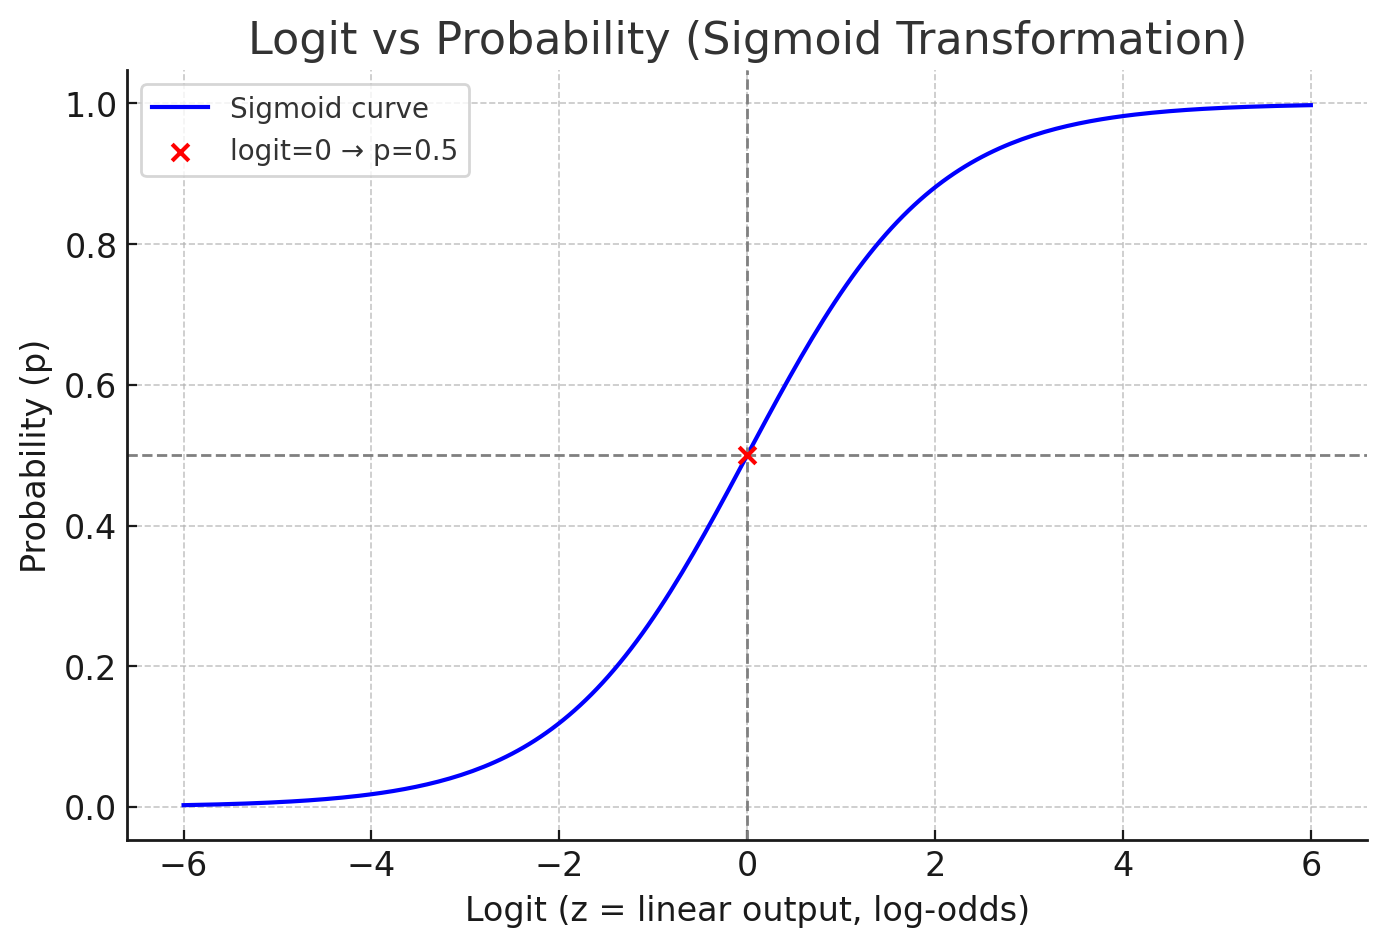

12. Answer - 0.5

13) Which variant of logistic regression is recommended when you have a categorical dependent variable with more than two values?
- Ordered logit regression
- Poisson regression
- Multinomial logistic regression
- Multiple Logistic regression

---

### 1) **Ordered Logit Regression (Ordinal Logistic Regression)**

* Used when the **dependent variable is ordinal** (categories with a natural order).
* Example: Customer satisfaction = {Very Unsatisfied, Unsatisfied, Neutral, Satisfied, Very Satisfied}.
* Here, order matters but differences between levels are not numerical.
* Model assumes cumulative probabilities of being in or below a category.

👉 Useful in survey analysis, Likert scale responses.

---

### 2) **Poisson Regression**

* Used when the **dependent variable is count data** (non-negative integers).
* Example: Number of accidents at an intersection per year.
* Assumes counts follow a **Poisson distribution**.
* Log link function is applied:

$$
\ln(\lambda) = b_0 + b_1x_1 + b_2x_2 + \dots
$$

where $\lambda$ = expected count.

👉 Useful in epidemiology, traffic studies, event counts.

---

### 3) **Multinomial Logistic Regression**

* Used when the **dependent variable is categorical with more than 2 classes (nominal)**, without order.
* Example: Choosing transport mode = {Car, Bus, Bike, Train}.
* Extends logistic regression to multiple categories by comparing each outcome to a baseline category.

👉 Useful in marketing, choice modeling.

---

### 4) **Multiple Logistic Regression (a.k.a. Multivariate Logistic Regression)**

* Regular **binary logistic regression** but with **multiple independent variables (predictors)**.
* Example: Predicting disease (Yes/No) based on Age, Blood Pressure, Cholesterol.
* Equation:

$$
\ln\left(\frac{p}{1-p}\right) = b_0 + b_1x_1 + b_2x_2 + \dots
$$

👉 Useful when predicting binary outcomes with many features.

---

✅ **Quick Summary:**

* **Ordered logit** → dependent variable = ordinal categories.
* **Poisson regression** → dependent variable = counts.
* **Multinomial logistic** → dependent variable = categorical (3+ unordered classes).
* **Multiple logistic** → dependent variable = binary, predictors = many.

---


👉 **Poisson regression is *not* logistic regression.**

Here’s the distinction:

---

### 🔹 Logistic Regression

* Used when the **dependent variable is categorical** (binary or multinomial).
* Uses the **logit link function**:

$$
\text{logit}(p) = \ln\left(\frac{p}{1-p}\right)
$$

* Goal: model **probabilities** of categories.

---

### 🔹 Poisson Regression

* Used when the **dependent variable is a count** (0, 1, 2, …).
* Uses the **log link function**:

$$
\ln(\lambda) = b_0 + b_1x_1 + \dots
$$

* Goal: model the **rate/expected count** of events.

---

### Why the confusion?

Both belong to the broader family called **Generalized Linear Models (GLMs)**.

* Logistic regression = GLM with logit link + binomial distribution.
* Poisson regression = GLM with log link + Poisson distribution.

So:

* ✅ Same family (GLMs).
* ❌ Not the same thing — Poisson regression is not a type of logistic regression.

---

Perfect 👍 Here’s a **comparison table** for the 4 regressions we discussed (Linear, Logistic, Multinomial Logistic, Poisson):

| **Regression Type**      | **Dependent Variable (Y)**            | **Distribution Assumed** | **Link Function**                      | **Use Case Example**                        |
| ------------------------ | ------------------------------------- | ------------------------ | -------------------------------------- | ------------------------------------------- |
| **Linear Regression**    | Continuous (any real value)           | Normal (Gaussian)        | Identity: $y = X\beta + \epsilon$      | Predicting house price from area & rooms    |
| **Logistic Regression**  | Binary categorical (0/1)              | Binomial                 | Logit: $\ln\left(\frac{p}{1-p}\right)$ | Predicting if email is spam (Yes/No)        |
| **Multinomial Logistic** | Categorical with >2 unordered classes | Multinomial              | Generalized logit (one vs baseline)    | Predicting transport choice (Car/Bus/Train) |
| **Poisson Regression**   | Count data (0,1,2,…)                  | Poisson                  | Log: $\ln(\lambda) = X\beta$           | Predicting number of accidents per year     |

---

✅ Quick way to remember:

* **Linear** → continuous Y.
* **Logistic** → binary Y.
* **Multinomial Logistic** → categorical Y (3+ classes, no order).
* **Poisson** → count Y.

---

Do you also want me to add **Ordered Logistic Regression** into this table (so it covers all 5 you asked about earlier)?


| Regression Type                                                                        | Description                                                                                                                                         | Dependent Variable Type                                | Key Assumptions                                                                      | When to Use                                                                                                                                |
| -------------------------------------------------------------------------------------- | --------------------------------------------------------------------------------------------------------------------------------------------------- | ------------------------------------------------------ | ------------------------------------------------------------------------------------ | ------------------------------------------------------------------------------------------------------------------------------------------ |
| **Ordered Logit Regression (Ordinal Logistic Regression)**                             | Models the relationship between independent variables and an **ordinal dependent variable** (a variable with categories that have a natural order). | Ordinal (e.g., “low”, “medium”, “high”)                | Assumes **proportional odds** (effect of predictors is consistent across thresholds) | Use when your outcome is ordered categories rather than continuous or nominal. Example: Survey rating (poor, average, excellent).          |
| **Poisson Regression**                                                                 | Models **count data**, i.e., the number of times an event occurs in a fixed period or space.                                                        | Non-negative integers (0, 1, 2…)                       | Mean ≈ variance (equidispersion), events are independent                             | Use for counts of events, e.g., number of customer complaints per month, number of accidents at a site. **Not logistic regression.**       |
| **Multinomial Logistic Regression**                                                    | Extension of logistic regression to model outcomes with **more than 2 unordered categories**.                                                       | Categorical (nominal, >2 categories, no natural order) | Assumes independence of irrelevant alternatives (IIA)                                | Use when your dependent variable has multiple classes without order. Example: Choice of transport (car, bus, bike).                        |
| **Multiple Logistic Regression (Binary Logistic Regression with multiple predictors)** | Standard logistic regression extended to **multiple independent variables**. Predicts probability of a **binary outcome**.                          | Binary (0/1, yes/no)                                   | Observations are independent, linearity in logit for continuous predictors           | Use when the outcome is yes/no and you have multiple predictors. Example: Predicting disease (yes/no) based on age, weight, and lifestyle. |


13. Answer - Multinomial logistic regression

14) Perform the following tasks for answering the remaining questions
- Rename the last column as Annual Income
- Remove the missing values from the dataset
- Change the labels of categorical data into numerical data using Label Encoder.
- Split the dataset into a train and test of proportions 70:30 and set the random state to 0.
- Build a Logistic Regression Model on the data.


Answer the following questions with the help of the above-created model. What is the accuracy score of the above model?

- 0.70 to 0.85
- None of the above
- 0.60 to 0.70
- 0.40 to 0.60

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             32561 non-null  int64 
 1   workclass       30725 non-null  object
 2   fnlwgt          32561 non-null  int64 
 3   education       32561 non-null  object
 4   education-num   32561 non-null  int64 
 5   marital-status  32561 non-null  object
 6   occupation      30718 non-null  object
 7   relationship    32561 non-null  object
 8   race            32561 non-null  object
 9   sex             32561 non-null  object
 10  capital-gain    32561 non-null  int64 
 11  capital-loss    32561 non-null  int64 
 12  hours-per-week  32561 non-null  int64 
 13  native-country  31978 non-null  object
 14  annual_income   32561 non-null  object
dtypes: int64(6), object(9)
memory usage: 3.7+ MB


In [ ]:
# Step 1 - last column is already annual income, so i am not renaming it

In [ ]:
# step 2 - remove missing values, df_2 is missing values removed but retains duplicates

In [ ]:
# We shall use df_2

In [ ]:
df_reg = df_2.copy()

In [ ]:
# Step 3 - Change the labels of categorical data into numerical data using Label Encoder.

In [ ]:
df_reg['annual_income'].unique()

array(['<=50K', '>50K'], dtype=object)

In [ ]:
# 1st let us modify target column , ourself

df_reg['annual_income'] = df_reg['annual_income'].replace('<=50K', 0)
df_reg['annual_income'] = df_reg['annual_income'].replace('>50K', 1)

df_reg['annual_income'] = df_reg['annual_income'].astype(int)

/tmp/ipython-input-2665019018.py:4: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_reg['annual_income'] = df_reg['annual_income'].replace('>50K', 1)


In [ ]:
df_reg.info()

<class 'pandas.core.frame.DataFrame'>
Index: 30162 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             30162 non-null  int64 
 1   workclass       30162 non-null  object
 2   fnlwgt          30162 non-null  int64 
 3   education       30162 non-null  object
 4   education-num   30162 non-null  int64 
 5   marital-status  30162 non-null  object
 6   occupation      30162 non-null  object
 7   relationship    30162 non-null  object
 8   race            30162 non-null  object
 9   sex             30162 non-null  object
 10  capital-gain    30162 non-null  int64 
 11  capital-loss    30162 non-null  int64 
 12  hours-per-week  30162 non-null  int64 
 13  native-country  30162 non-null  object
 14  annual_income   30162 non-null  int64 
dtypes: int64(7), object(8)
memory usage: 3.7+ MB


In [ ]:
df_reg['annual_income'].value_counts()

,count
annual_income,
0,22654
1,7508


In [ ]:
df_2['annual_income'].value_counts()

,count
annual_income,
<=50K,22654
>50K,7508


In [ ]:
from sklearn.preprocessing import LabelEncoder

In [ ]:
encoders = {}
mappings = {}
for i in df_reg.columns:
  if df_reg[i].dtype == 'object':
    le = LabelEncoder() # new instance every time
    df_reg[i] = le.fit_transform(df_reg[i])
    encoders[i] = le # storing the correct encoder for each column
    mappings[i] = dict(zip(le.classes_,le.transform(le.classes_)))

In [ ]:
encoders

{'workclass': LabelEncoder(),
 'education': LabelEncoder(),
 'marital-status': LabelEncoder(),
 'occupation': LabelEncoder(),
 'relationship': LabelEncoder(),
 'race': LabelEncoder(),
 'sex': LabelEncoder(),
 'native-country': LabelEncoder()}

In [ ]:
mappings

{'workclass': {'Federal-gov': np.int64(0),
  'Local-gov': np.int64(1),
  'Private': np.int64(2),
  'Self-emp-inc': np.int64(3),
  'Self-emp-not-inc': np.int64(4),
  'State-gov': np.int64(5),
  'Without-pay': np.int64(6)},
 'education': {'10th': np.int64(0),
  '11th': np.int64(1),
  '12th': np.int64(2),
  '1st-4th': np.int64(3),
  '5th-6th': np.int64(4),
  '7th-8th': np.int64(5),
  '9th': np.int64(6),
  'Assoc-acdm': np.int64(7),
  'Assoc-voc': np.int64(8),
  'Bachelors': np.int64(9),
  'Doctorate': np.int64(10),
  'HS-grad': np.int64(11),
  'Masters': np.int64(12),
  'Preschool': np.int64(13),
  'Prof-school': np.int64(14),
  'Some-college': np.int64(15)},
 'marital-status': {'Divorced': np.int64(0),
  'Married-AF-spouse': np.int64(1),
  'Married-civ-spouse': np.int64(2),
  'Married-spouse-absent': np.int64(3),
  'Never-married': np.int64(4),
  'Separated': np.int64(5),
  'Widowed': np.int64(6)},
 'occupation': {'Adm-clerical': np.int64(0),
  'Armed-Forces': np.int64(1),
  'Craft-repai

In [ ]:
df_reg.info()

<class 'pandas.core.frame.DataFrame'>
Index: 30162 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   age             30162 non-null  int64
 1   workclass       30162 non-null  int64
 2   fnlwgt          30162 non-null  int64
 3   education       30162 non-null  int64
 4   education-num   30162 non-null  int64
 5   marital-status  30162 non-null  int64
 6   occupation      30162 non-null  int64
 7   relationship    30162 non-null  int64
 8   race            30162 non-null  int64
 9   sex             30162 non-null  int64
 10  capital-gain    30162 non-null  int64
 11  capital-loss    30162 non-null  int64
 12  hours-per-week  30162 non-null  int64
 13  native-country  30162 non-null  int64
 14  annual_income   30162 non-null  int64
dtypes: int64(15)
memory usage: 3.7 MB


In [ ]:
# Step 4 - Split the dataset into a train and test of proportions 70:30 and set the random state to 0.

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

In [ ]:
X = df_reg.drop('annual_income',axis =1)

In [ ]:
X.info()

<class 'pandas.core.frame.DataFrame'>
Index: 30162 entries, 0 to 32560
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   age             30162 non-null  int64
 1   workclass       30162 non-null  int64
 2   fnlwgt          30162 non-null  int64
 3   education       30162 non-null  int64
 4   education-num   30162 non-null  int64
 5   marital-status  30162 non-null  int64
 6   occupation      30162 non-null  int64
 7   relationship    30162 non-null  int64
 8   race            30162 non-null  int64
 9   sex             30162 non-null  int64
 10  capital-gain    30162 non-null  int64
 11  capital-loss    30162 non-null  int64
 12  hours-per-week  30162 non-null  int64
 13  native-country  30162 non-null  int64
dtypes: int64(14)
memory usage: 3.5 MB


In [ ]:
y = df_reg['annual_income']

In [ ]:
y

,annual_income
0,0
1,0
2,0
3,0
4,0
...,...
32556,0
32557,1
32558,0
32559,0


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=0)

In [ ]:
X_train.shape

(21113, 14)

In [ ]:
X_test.shape

(9049, 14)

In [ ]:
y_train.shape

(21113,)

In [ ]:
y_test.shape

(9049,)

In [ ]:
# Step 5 - Build a Logistic Regression Model on the data.

In [ ]:
lr = LogisticRegression()

In [ ]:
lr.fit(X_train,y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression()

In [ ]:
y_pred = lr.predict(X_test)

In [ ]:
y_pred

array([0, 0, 0, ..., 1, 0, 0])

In [ ]:
y_test

,annual_income
2135,0
15639,0
29059,0
27523,0
9280,0
...,...
16826,0
25246,0
18980,1
953,0


In [ ]:
# accuracy

In [ ]:
accuracy_score(y_test,y_pred) #actual and then predicted

0.7926842745054702

In [ ]:
accuracy_score(y_test,y_pred) * 100

79.26842745054702

In [ ]:
# Accuracy 0.79 that is 0.70 to 0.85

14. Answer - 0.70 to 0.85

15) Perform the following tasks for answering the remaining questions
- Rename the last column as Annual Income
- Remove the missing values from the dataset
- Change the labels of categorical data into numerical data using Label Encoder.
- Split the dataset into a train and test of proportions 70:30 and set the random state to 0.
- Build a Logistic Regression Model on the data.

Answer the following questions with the help of the above-created model. What is the specificity of the above model?

- 0.20 to 0.30
- None of the above
- 0.30 to 0.40
- 0.50 to 0.60

In classification (especially binary classification like Logistic Regression), we evaluate models with different metrics.

---

### ✅ Specificity (True Negative Rate, TNR)

**Definition:**
Specificity measures the proportion of **actual negatives** that are correctly identified as negatives.

$$
\text{Specificity} = \frac{\text{True Negatives (TN)}}{\text{True Negatives (TN)} + \text{False Positives (FP)}}
$$

---

### 📊 Example Confusion Matrix

|                     | Predicted Positive  | Predicted Negative  |
| ------------------- | ------------------- | ------------------- |
| **Actual Positive** | True Positive (TP)  | False Negative (FN) |
| **Actual Negative** | False Positive (FP) | True Negative (TN)  |

* **Sensitivity / Recall (True Positive Rate):** $TP / (TP + FN)$
* **Specificity (True Negative Rate):** $TN / (TN + FP)$

---

### 🔎 Intuition

* **Sensitivity (Recall):** How well the model detects the **positives**.
* **Specificity:** How well the model detects the **negatives**.

---

### 🎯 Example

Suppose a medical test for a disease:

* 100 patients **without disease** → 90 correctly identified as negative, 10 misclassified as positive.
* Then:

$$
\text{Specificity} = \frac{TN}{TN + FP} = \frac{90}{90+10} = 0.90
$$

So, the test is **90% specific**.

---

👉 In practice:

* **High specificity** = few false alarms (good at ruling out negatives).
* **High sensitivity** = good at detecting positives (few missed cases).

---

In [ ]:
# sklearn.metrics.confusion_matrix(y_true, y_pred, *, labels=None, sample_weight=None, normalize=None)

In [ ]:
# Returns:
# C
# ndarray of shape (n_classes, n_classes)
# Confusion matrix whose i-th row and j-th column entry indicates the number of samples with true label being i-th class and predicted label being j-th class.

**sklearn confusion metrix input parameters order and output**

sklearn.metrics.confusion_matrix(y_true, y_pred, *, labels=None, sample_weight=None, normalize=None)

Returns:
C
ndarray of shape (n_classes, n_classes)
Confusion matrix whose i-th row and j-th column entry indicates the number of samples with true label being i-th class and predicted label being j-th class.

---
### Get the Confusion Matrix

```python
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)
```

This gives you:

$$
\begin{bmatrix}
TN & FP \\
FN & TP
\end{bmatrix}
$$

---

### Step 3: Calculate Specificity

```python
TN, FP, FN, TP = cm.ravel()

specificity = TN / (TN + FP)
print("Specificity:", specificity)
```

---

✅ Output will be a value between **0 and 1**.
Example: `Specificity: 0.92` → means 92% of actual negatives were correctly classified.

---

⚡ Shortcut: you can also use `recall_score` with `pos_label=0`:

```python
from sklearn.metrics import recall_score

specificity = recall_score(y_test, y_pred, pos_label=0)
print("Specificity:", specificity)
```

---


| Metric                                                  | Formula              | Intuition                                                               |
| ------------------------------------------------------- | -------------------- | ----------------------------------------------------------------------- |
| **Precision (Positive Predictive Value)**               | $\frac{TP}{TP + FP}$ | Out of predicted positives, how many are actually positive?             |
| **Recall / Sensitivity (True Positive Rate)**           | $\frac{TP}{TP + FN}$ | Out of actual positives, how many did we correctly predict as positive? |
| **Specificity (True Negative Rate)**                    | $\frac{TN}{TN + FP}$ | Out of actual negatives, how many did we correctly predict as negative? |
| **Negative Precision (Negative Predictive Value, NPV)** | $\frac{TN}{TN + FN}$ | Out of predicted negatives, how many are actually negative?             |


In [ ]:
from sklearn.metrics import confusion_matrix
from sklearn.metrics import recall_score
from sklearn.metrics import precision_score

In [ ]:
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)

Confusion Matrix:
 [[6627  137]
 [1739  546]]


In [ ]:
TN, FP, FN, TP = cm.ravel() # similar to flatten but when memory and performance are critical

specificity = TN / (TN + FP)
print("Specificity:", specificity)

Specificity: 0.979745712596097


In [ ]:
specificity = recall_score(y_test, y_pred, pos_label=0)
print("Specificity:", specificity)

Specificity: 0.979745712596097


Specificity - 0.9797

15. Answer - None of the above

16) Perform the following tasks for answering the remaining questions
- Rename the last column as Annual Income
- Remove the missing values from the dataset
- Change the labels of categorical data into numerical data using Label Encoder.
- Split the dataset into a train and test of proportions 70:30 and set the random state to 0.
- Build a Logistic Regression Model on the data.

Answer the following questions with the help of the above-created model. What is the model’s precision when the target is False?

- 0.60 to 0.70
- None of the above
- 0.40 to 0.60
- 0.70 to 0.80

In [ ]:
# Negative Precision (Negative Predictive Value, NPV)

In [ ]:
neg_precision = precision_score(y_test, y_pred, pos_label=0)
print("Negative Precision Value:", neg_precision)

Negative Precision Value: 0.7921348314606742


In [ ]:
pos_precision = precision_score(y_test, y_pred, pos_label=1)
print("Positive Precision Value:", pos_precision)

Positive Precision Value: 0.7994143484626647


Precision when target is false - 0.7921348314606742

In [ ]:
sensitivity = recall_score(y_test, y_pred, pos_label=1)

# Specificity (recall for negatives)
specificity = recall_score(y_test, y_pred, pos_label=0)

print("Sensitivity:", sensitivity)
print("Specificity:", specificity)

Sensitivity: 0.23894967177242887
Specificity: 0.979745712596097


In [ ]:
# Metrics
precision_pos = TP / (TP + FP)                 # Positive Precision
recall_pos    = TP / (TP + FN)                 # Sensitivity (Recall for positives)
specificity   = TN / (TN + FP)                 # Recall for negatives
precision_neg = TN / (TN + FN)                 # Negative Precision (NPV)

print("Precision (PPV):", precision_pos)
print("Recall / Sensitivity (TPR):", recall_pos)
print("Specificity (TNR):", specificity)
print("Negative Precision (NPV):", precision_neg)


Precision (PPV): 0.7994143484626647
Recall / Sensitivity (TPR): 0.23894967177242887
Specificity (TNR): 0.979745712596097
Negative Precision (NPV): 0.7921348314606742


16. Answer - None of the above

**Correct Answer : 0.70 to 0.80**

Precision when target is false

17) Perform the following tasks for answering the remaining questions
- Rename the last column as Annual Income
- Remove the missing values from the dataset
- Change the labels of categorical data into numerical data using Label Encoder.
- Split the dataset into a train and test of proportions 70:30 and set the random state to 0.
- Build a Logistic Regression Model on the data.

Answer the following questions with the help of the above-created model. What is the total support value from the above model?

- 9847
- 10000
- 9049
- 9032

**support** appear when you run `classification_report` in scikit-learn.

---

### ✅ What is Support?

**Support** = the **number of true instances** for each class in your dataset.

In other words:

* For class `0` → how many actual samples in `y_test` are labeled `0`
* For class `1` → how many actual samples in `y_test` are labeled `1`

It’s basically the **class frequency**.

---

### 📊 Example

Suppose `y_test` has 10 samples:

```
y_test = [0, 0, 0, 1, 1, 1, 1, 1, 1, 1]
```

* Support for class 0 = 3
* Support for class 1 = 7

So in the report you’ll see something like:

```
              precision    recall  f1-score   support
           0       0.80      0.67      0.73         3
           1       0.90      0.95      0.92         7
```

Here, `support=3` for class 0 and `support=7` for class 1.

---

### ⚡ Why is support useful?

* It shows **how many samples contribute** to each metric.
* It helps you see if your dataset is **imbalanced** (e.g., 95% class 0, 5% class 1).
* Metrics like **accuracy** can be misleading without looking at support.

---

### ✅ In Python (scikit-learn)

```python
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))
```

This will show `precision`, `recall`, `f1-score`, and `support` for each class.

---

In [ ]:
from sklearn.metrics import classification_report

In [ ]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.79      0.98      0.88      6764
           1       0.80      0.24      0.37      2285

    accuracy                           0.79      9049
   macro avg       0.80      0.61      0.62      9049
weighted avg       0.79      0.79      0.75      9049



total support value is 9049

support itself is only actual counts, nothing to do with predicted counts.

Support is total test size here

17. Answer - 9049

18) Perform the following tasks for answering the remaining questions
- Rename the last column as Annual Income
- Remove the missing values from the dataset
- Change the labels of categorical data into numerical data using Label Encoder.
- Split the dataset into a train and test of proportions 70:30 and set the random state to 0.
- Build a Logistic Regression Model on the data.

Answer the following questions with the help of the above-created model. What is the f1 score of the above model when the target is True?

- 0.90 to 0.99
- 0.30 to 0.40
- 0.40 to 0.50
- 0.60 to 0.70

---

### 🔹 What is F1-score?

The **F1-score** is the **harmonic mean** of **precision** and **recall**:

$$
F1 = 2 \times \frac{(\text{Precision} \times \text{Recall})}{(\text{Precision} + \text{Recall})}
$$

* Precision = How many predicted positives were actually positive.
* Recall = How many actual positives were correctly predicted.
* F1 balances the two.

---

### 🔹 Why harmonic mean?

* If either **precision** or **recall** is very low, the F1-score also becomes low.
* It avoids a misleading high average if one metric is large and the other is small.

Example:

* Precision = 1.0, Recall = 0.0 → F1 = 0 (not 0.5, which arithmetic mean would give).

---

### 🔹 Interpretation

* **High F1 (close to 1)** → good balance between precision and recall.
* **Low F1 (close to 0)** → imbalance or both poor.

---

### 🔹 Your Report Example

For **class 1**:

* Precision = 0.80
* Recall = 0.24

$$
F1 = 2 \times \frac{(0.80 \times 0.24)}{(0.80 + 0.24)} \approx 0.37
$$

👉 That matches your report.

---

⚖️ **So, F1 is best used when you want a single score that considers both false positives & false negatives.**

In [ ]:
from sklearn.metrics import f1_score

In [ ]:
# F1 score for class 1 (positive class)
f1_pos = f1_score(y_test, y_pred, pos_label=1)

# F1 score for class 0 (negative class)
f1_neg = f1_score(y_test, y_pred, pos_label=0)

# Macro F1 (average of both classes)
f1_macro = f1_score(y_test, y_pred, average='macro')

# Weighted F1 (weighted by support)
f1_weighted = f1_score(y_test, y_pred, average='weighted')

print("F1-score (class 0):", f1_neg)
print("F1-score (class 1):", f1_pos)
print("Macro F1:", f1_macro)
print("Weighted F1:", f1_weighted)

F1-score (class 0): 0.8760079312623926
F1-score (class 1): 0.36792452830188677
Macro F1: 0.6219662297821397
Weighted F1: 0.7477097131427379


In [ ]:
f1_score(y_test, y_pred, pos_label=1)

0.36792452830188677

f1 score for target is true (pos_label=1) is 0.37

18. Answer - 0.30 to 0.40

19) Perform the following tasks for answering the remaining questions
- Rename the last column as Annual Income
- Remove the missing values from the dataset
- Change the labels of categorical data into numerical data using Label Encoder.
- Split the dataset into a train and test of proportions 70:30 and set the random state to 0.
- Build a Logistic Regression Model on the data.

Answer the following questions with the help of the above-created model. How many records are correctly classified by the model?

- 7000
- 7173
- 7043
- None of the above

In [ ]:
correct_predictions = (y_test == y_pred).sum()

# OR using accuracy score * total samples
correct_predictions2 = accuracy_score(y_test, y_pred) * len(y_test)

print("Correctly classified records:", correct_predictions)
print("Correctly classified records (method 2):", int(correct_predictions2))

Correctly classified records: 7173
Correctly classified records (method 2): 7173


In [ ]:
TP + TN #from confusion matrix flattened

np.int64(7173)

19. Answer - 7173

20) Choose the code which is used to perform reset indexes in the original data frame.
- data.reset_index(inplace=False)
- data.reset_index(inplace=True)
- data.reset(inplace=False)
- data.reset(inplace=True)

In [ ]:
import pandas as pd

# Example DataFrame with custom index
data = pd.DataFrame({
    'Name': ['A', 'B', 'C'],
    'Score': [10, 20, 30]
}, index=[101, 102, 103])

print("Original DataFrame:\n", data)

# 1️⃣ Reset index without modifying the original (inplace=False)
df_new = data.reset_index(inplace=False)
print("\nAfter reset_index(inplace=False) -> New DataFrame:\n", df_new)
print("\nOriginal DataFrame remains unchanged:\n", data)

# 2️⃣ Reset index with inplace=True (modifies original DataFrame)
data.reset_index(inplace=True)
print("\nAfter reset_index(inplace=True) -> Original DataFrame changed:\n", data)

Original DataFrame:
     Name  Score
101    A     10
102    B     20
103    C     30

After reset_index(inplace=False) -> New DataFrame:
    index Name  Score
0    101    A     10
1    102    B     20
2    103    C     30

Original DataFrame remains unchanged:
     Name  Score
101    A     10
102    B     20
103    C     30

After reset_index(inplace=True) -> Original DataFrame changed:
    index Name  Score
0    101    A     10
1    102    B     20
2    103    C     30


In [ ]:
data = pd.DataFrame({
    'Name': ['A', 'B', 'C'],
    'Score': [10, 20, 30]
}, index=[101, 102, 103])

print(data)

data.reset_index(drop=True, inplace=True)  # to not include old index as a column
print(data)

    Name  Score
101    A     10
102    B     20
103    C     30
  Name  Score
0    A     10
1    B     20
2    C     30


.reset is not valid method name

20. Answer - data.reset_index(inplace=True)

21) What is the cost function used in Binary Logistic Regression?
- None of the options are correct
- Sum Squared Error
- Categorical Cross Entropy
- Log Loss

---

### 1️⃣ What is a Cost Function?

* The **cost function** measures **how wrong the model is** on the training data.
* The goal of training is to **minimize this cost**.
* In Linear Regression, we use **Mean Squared Error (MSE)**.
* In Logistic Regression, we use **Log Loss / Cross-Entropy Loss**.

---

### 2️⃣ Logistic Regression Cost Function

For a single training example:

$$
\text{Cost}(h_\theta(x), y) =
\begin{cases}
- \log(h_\theta(x)) & \text{if } y = 1 \\
- \log(1 - h_\theta(x)) & \text{if } y = 0
\end{cases}
$$

* $h_\theta(x) = \sigma(\theta^T x) = \frac{1}{1 + e^{-\theta^T x}}$ → predicted probability of class 1
* $y$ → actual label (0 or 1)

---

### 3️⃣ Cost for the whole training set

$$
J(\theta) = -\frac{1}{m} \sum_{i=1}^{m} \Big[ y^{(i)} \log(h_\theta(x^{(i)})) + (1 - y^{(i)}) \log(1 - h_\theta(x^{(i)})) \Big]
$$

Where:

* $m$ = number of training samples
* $h_\theta(x^{(i)})$ = predicted probability for the $i$-th sample

---

### 4️⃣ Intuition

* If the model predicts correctly:

  * $y=1, h_\theta(x) \approx 1$ → $-\log(1) = 0$ → low cost
  * $y=0, h_\theta(x) \approx 0$ → $-\log(1) = 0$ → low cost
* If prediction is wrong:

  * $y=1, h_\theta(x) \approx 0$ → $-\log(0) $ → very high cost
  * $y=0, h_\theta(x) \approx 1$ → $-\log(0) $ → very high cost

The cost function **penalizes wrong predictions heavily**.

---

✅ Key Points:

* Called **Log Loss / Cross-Entropy Loss**.
* Always non-negative, lower is better.
* Used by **Gradient Descent** to update parameters.

---


In [ ]:
import numpy as np

# Example: predicted probabilities and actual labels
y = np.array([1, 0, 1, 0])
h = np.array([0.9, 0.2, 0.8, 0.1])  # predicted probabilities for class 1

# Logistic Regression cost (average over all samples)
m = len(y)
cost = - (1/m) * np.sum(y*np.log(h) + (1-y)*np.log(1-h))
print("Cost:", cost)

Cost: 0.16425203348601802


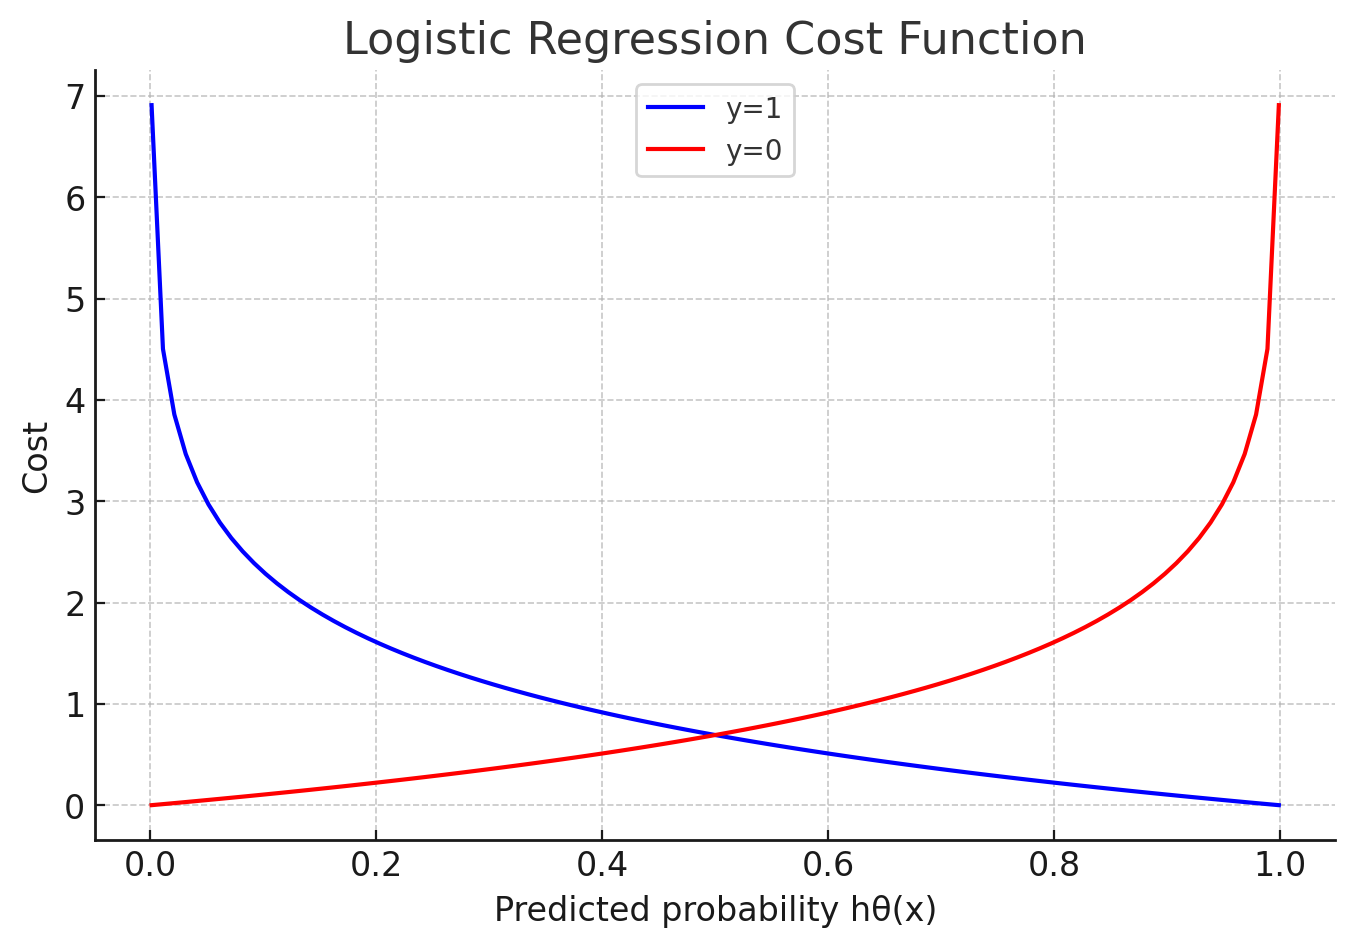

Here’s the graph for the **Logistic Regression cost function** ✅

* **Blue curve (y=1)** → cost when the true label is 1.

  * Cost is very low when prediction $h_\theta(x)$ is near 1.
  * Cost shoots up as prediction approaches 0.

* **Red curve (y=0)** → cost when the true label is 0.

  * Cost is very low when prediction $h_\theta(x)$ is near 0.
  * Cost shoots up as prediction approaches 1.

---

🔹 **Takeaway:**

* Wrong predictions are penalized heavily.
* Correct predictions have very low cost.
* This is why Logistic Regression encourages predictions close to the true labels.

---


**For Binary Logistic Regression, the cost function used is Log Loss (also called Binary Cross-Entropy).**

Sum of Squared Errors (SSE) or Mean Squared Error (MSE) is the cost function for Linear Regression.

**Categorical Cross-Entropy** is used for **multi-class classification** where:

* There are **more than 2 classes** (e.g., classes A, B, C).
* The model outputs a **probability distribution over all classes** using **softmax**.
* The cost function penalizes the model if the predicted probability for the **true class** is low.

**Formula for Categorical Cross-Entropy**:

$$
\text{Cost} = - \frac{1}{m} \sum_{i=1}^{m} \sum_{c=1}^{C} y_{i,c} \log(\hat{y}_{i,c})
$$

Where:

* $C$ = number of classes
* $y_{i,c}$ = 1 if sample $i$ belongs to class $c$, else 0
* $\hat{y}_{i,c}$ = predicted probability of class $c$ for sample $i$

---


21. Answer - Log Loss

22) Which below method is used to find the best fitting line in logistic regression
- Least Square Method
- None of the above
- Maximum Likelihood
- Sigmoid

The correct answer is: **Maximum Likelihood** ✅

Here’s why:

* In **Linear Regression**, we use **Least Squares** to minimize the squared errors.
* In **Logistic Regression**, the output is **probabilities** (between 0 and 1), not continuous values.
* Therefore, **Least Squares doesn’t work well** for logistic regression.

Instead, we use **Maximum Likelihood Estimation (MLE)**:

* MLE finds the parameter values (weights) that **maximize the likelihood of observing the given data**.
* For binary logistic regression, the likelihood for $m$ samples is:

$$
L(\theta) = \prod_{i=1}^{m} \hat{y}_i^{y_i} (1 - \hat{y}_i)^{1 - y_i}
$$

* We usually maximize the **log-likelihood** (because it’s easier to compute):

$$
\text{Log-Likelihood} = \sum_{i=1}^{m} \big[ y_i \log(\hat{y}_i) + (1-y_i) \log(1-\hat{y}_i) \big]
$$

* This is exactly the **Log Loss / Binary Cross-Entropy** cost function we minimize during training.

**Other options:**

* **Least Squares Method** → used for linear regression.
* **Sigmoid** → just the activation function, not a method to fit the line.
* **None of the above** → incorrect.

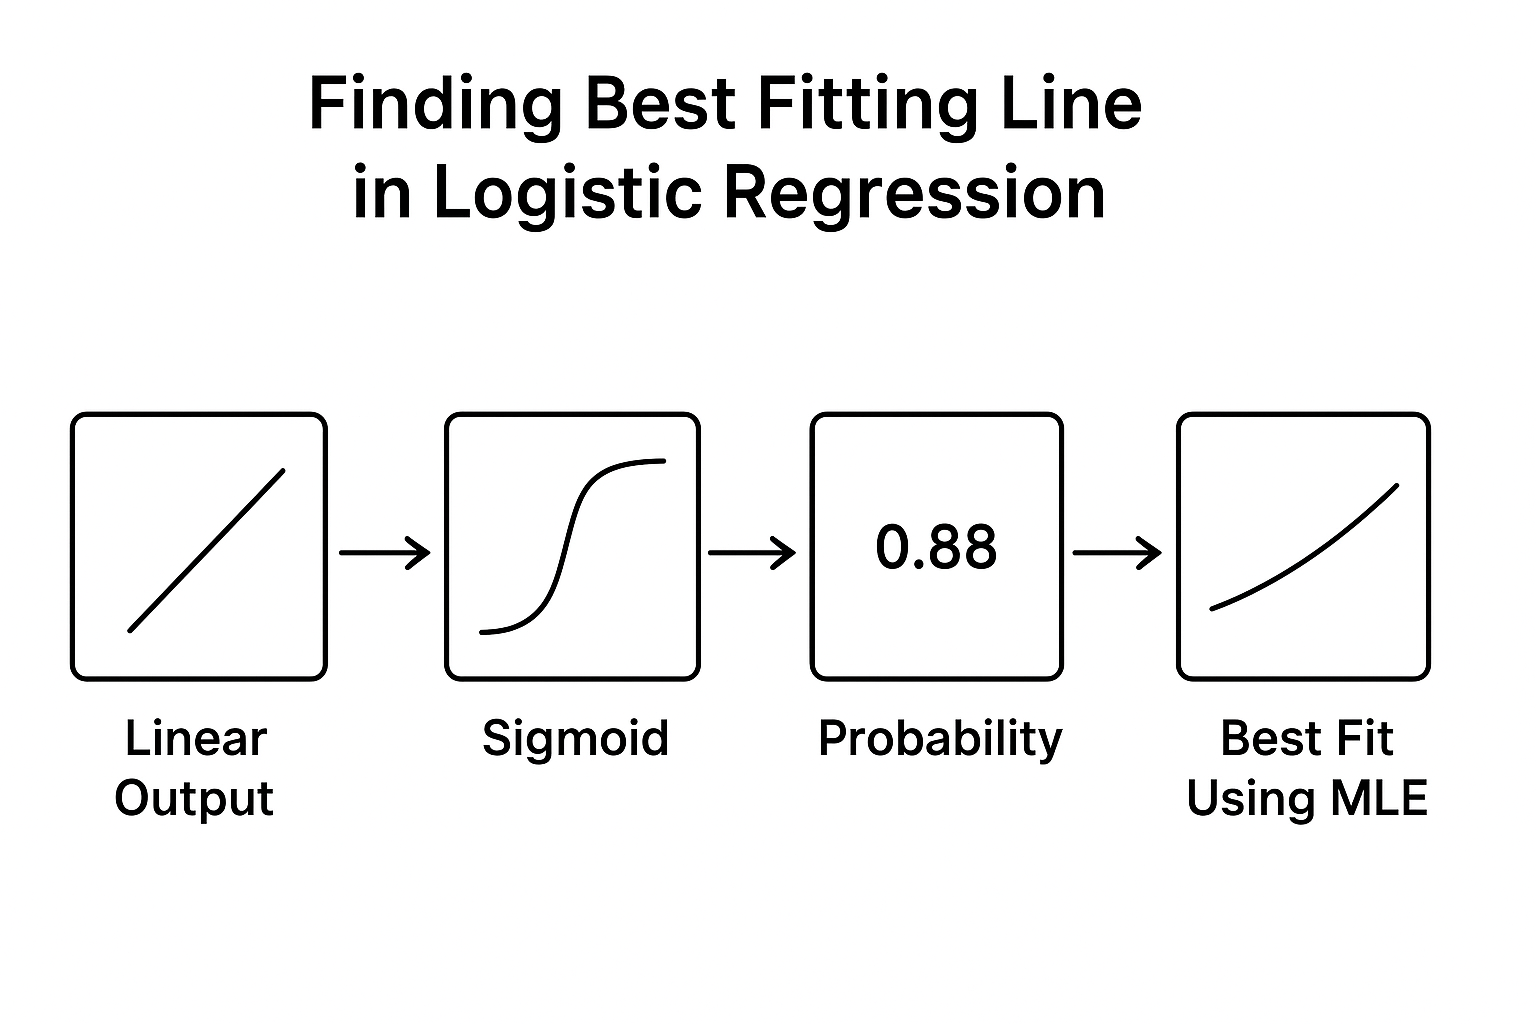

22. Answer - Maximum Likelihood

23) What is the relation between Sensitivity and Specificity?
- No relation between both
- Sensitivity Increases Specificity Decreases
- Sensitivity Increases Specificity Increases

**Sensitivity Increases → Specificity Decreases** ✅

Here’s why:

* **Sensitivity** (True Positive Rate) measures the proportion of actual positives correctly identified.
* **Specificity** (True Negative Rate) measures the proportion of actual negatives correctly identified.

There’s a trade-off between them:

* If you set a test threshold to catch more positives (increase sensitivity), you often misclassify more negatives as positives → specificity decreases.
* If you set the threshold to correctly identify more negatives (increase specificity), you might miss some positives → sensitivity decreases.

So, **they are inversely related** in most practical scenarios.

23. Answer - Sensitivity Increases Specificity Decreases

24) 1. Use the creditworthiness data for the following questions, Don’t perform any Data cleaning or pre-processing before answering the questions.

What is the entropy of the column Htype using the formula (-1 * np.sum(np.log2(probs) * probs)) where probs is the list of probability of each unique item in the column?
- 1.14
- 0.56
- 9.85
- 5.75

In [ ]:
df_credit_columns_descripton = pd.read_excel('/content/CreditWorthiness.xlsx', sheet_name=1)

In [ ]:
df_credit_columns_descripton

,Unnamed: 0,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,Variables,Data Type,Description
3,NaN,NaN,Cbal,CATEGORICAL,Balance in the checking account in Rs. (rupees...
4,NaN,NaN,Cdur,NUMERICAL,The duration of the credit in months (numerical)
5,NaN,NaN,Chist,CATEGORICAL,"The pattern of credit dues payment over time, ..."
6,NaN,NaN,Cpur,CATEGORICAL,Purpose of the loan – for a variety of needs f...
7,NaN,NaN,Camt,NUMERICAL,The actual amount under credit/loan in Rs. (ru...
8,NaN,NaN,Sbal,CATEGORICAL,Balance in the savings bank account in Rs. (ru...
9,NaN,NaN,Edur,CATEGORICAL,"Duration of employment, need to understand fro..."


In [ ]:
df_credit = pd.read_excel('/content/CreditWorthiness.xlsx', sheet_name="Data")

In [ ]:
df_credit

,Cbal,Cdur,Chist,Cpur,Camt,Sbal,Edur,InRate,MSG,Oparties,...,Prop,age,inPlans,Htype,NumCred,JobType,Ndepend,telephone,foreign,creditScore
0,0 <= Rs. < 2000,9,all settled till now,Business,13790,Rs. < 1000,1 to 4 years,2,married or widowed male,no one,...,real estate,27,bank,own,1,employee with official position,1,yes,no,good
1,0 <= Rs. < 2000,15,dues not paid earlier,electronics,15250,no savings account,more than 7 years,4,single male,"yes, guarantor",...,real estate,50,none,own,2,employee with official position,1,yes,no,good
2,0 <= Rs. < 2000,36,none taken/all settled,Business,19410,Rs. < 1000,more than 7 years,4,single male,no one,...,Unknown,61,none,free,1,"employed either in management, self or in high...",1,yes,no,bad
3,0 <= Rs. < 2000,48,none taken/all settled,Business,144090,Rs. < 1000,1 to 4 years,2,single male,no one,...,Other cars etc.,25,none,own,1,employee with official position,1,yes,no,bad
4,no checking account,24,all settled till now,electronics,31690,Rs. < 1000,less than 1 year,4,divorced or separated or married female,no one,...,life insurance/building society,26,none,own,1,employee with official position,1,yes,no,good
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,no checking account,6,all settled,second hand vehicle,7710,no savings account,1 to 4 years,1,single male,"yes, guarantor",...,real estate,26,stores,own,1,resident unskilled,2,no,no,good
996,0 <= Rs. < 2000,12,all settled till now,electronics,64560,no savings account,not employed,2,single male,no one,...,Unknown,52,none,own,1,"employed either in management, self or in high...",1,yes,no,bad
997,no checking account,36,dues not paid earlier,electronics,95540,Rs. < 1000,1 to 4 years,2,divorced or separated or married female,no one,...,Other cars etc.,31,stores,own,2,employee with official position,1,no,no,good
998,Rs. >=2000,18,all settled till now,second hand vehicle,19490,Rs. < 1000,more than 7 years,3,divorced or separated or married female,no one,...,Other cars etc.,23,none,own,1,"employed either in management, self or in high...",1,no,no,good


In [ ]:
df_credit.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 21 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Cbal         1000 non-null   object
 1   Cdur         1000 non-null   int64 
 2   Chist        1000 non-null   object
 3   Cpur         1000 non-null   object
 4   Camt         1000 non-null   int64 
 5   Sbal         1000 non-null   object
 6   Edur         1000 non-null   object
 7   InRate       1000 non-null   int64 
 8   MSG          1000 non-null   object
 9   Oparties     1000 non-null   object
 10  Rdur         1000 non-null   object
 11  Prop         1000 non-null   object
 12  age          1000 non-null   int64 
 13  inPlans      1000 non-null   object
 14  Htype        1000 non-null   object
 15  NumCred      1000 non-null   int64 
 16  JobType      1000 non-null   object
 17  Ndepend      1000 non-null   int64 
 18  telephone    1000 non-null   object
 19  foreign      1000 non-null  

In [ ]:
df_credit['Htype'].value_counts()

,count
Htype,
own,713
pays rent,179
free,108


The formula you mentioned is:

$$
\text{Entropy} = - \sum_i p_i \log_2(p_i)
$$

where $p_i$ is the probability of each unique value in the column.


The value_counts() method in Pandas is used to count the occurrences of unique values in a Series or DataFrame column. It returns a new Series where the index represents the unique values and the values represent their respective counts. [1]  
Key Features and Usage:

- Counting Unique Values: The primary purpose is to determine the frequency of each distinct element within a given dataset.
-  Default Sorting: By default, the results are sorted in descending order, with the most frequent values appearing first.
- Ignoring Missing Values: Missing values (NaN/NA) are ignored by default.
- Parameters for Customization:
	- normalize=True: Returns the relative frequencies (percentages) instead of the raw counts.
	- sort=False: Prevents sorting of the output Series.
	- ascending=True: Sorts the output in ascending order (least frequent values first).
	- bins: For numerical data, this parameter can be used to group values into discrete bins and count occurrences within each bin.
	- dropna=False: Includes missing values in the count.

In [ ]:
# Step 1: Calculate value counts normalized (gives probabilities)
probs = df_credit['Htype'].value_counts(normalize=True).values

In [ ]:
probs

array([0.713, 0.179, 0.108])

In [ ]:
# given formula
entropy = -1 * np.sum(np.log2(probs) * probs)

In [ ]:
entropy

np.float64(1.1390117663236383)

entropy is 1.1390 rounded to 1.14

24. Answer - 1.14

25) 1. Use the creditworthiness data for the following questions, Don’t perform any Data cleaning or pre-processing before answering the questions.

What is the total number of columns obtained post running the command pandas get_dummies in the raw data when the Initial columns count is 21?
- 97
- 21
- 65
- 48

In [ ]:
df_credit.shape # yes, as mentioned there is 21 columns

(1000, 21)

In [ ]:
df_credit.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 21 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Cbal         1000 non-null   object
 1   Cdur         1000 non-null   int64 
 2   Chist        1000 non-null   object
 3   Cpur         1000 non-null   object
 4   Camt         1000 non-null   int64 
 5   Sbal         1000 non-null   object
 6   Edur         1000 non-null   object
 7   InRate       1000 non-null   int64 
 8   MSG          1000 non-null   object
 9   Oparties     1000 non-null   object
 10  Rdur         1000 non-null   object
 11  Prop         1000 non-null   object
 12  age          1000 non-null   int64 
 13  inPlans      1000 non-null   object
 14  Htype        1000 non-null   object
 15  NumCred      1000 non-null   int64 
 16  JobType      1000 non-null   object
 17  Ndepend      1000 non-null   int64 
 18  telephone    1000 non-null   object
 19  foreign      1000 non-null  

In [ ]:
object_cols = df_credit.select_dtypes(include='object').columns

In [ ]:
object_cols

Index(['Cbal', 'Chist', 'Cpur', 'Sbal', 'Edur', 'MSG', 'Oparties', 'Rdur',
       'Prop', 'inPlans', 'Htype', 'JobType', 'telephone', 'foreign',
       'creditScore'],
      dtype='object')

In [ ]:
nunique_dict_for_credit = {col: df_credit[col].nunique() for col in object_cols}

In [ ]:
nunique_dict_for_credit

{'Cbal': 4,
 'Chist': 4,
 'Cpur': 10,
 'Sbal': 5,
 'Edur': 5,
 'MSG': 4,
 'Oparties': 3,
 'Rdur': 4,
 'Prop': 4,
 'inPlans': 3,
 'Htype': 3,
 'JobType': 4,
 'telephone': 2,
 'foreign': 2,
 'creditScore': 2}

In [ ]:
sum(nunique_dict_for_credit.values())

59

In [ ]:
# total 59 minus number of object cols

In [ ]:
len(object_cols)

15

In [ ]:
sum(nunique_dict_for_credit.values()) - len(object_cols)

44

In [ ]:
# 44 cols will be added to 21 initial cols if get_dummies applied

In [ ]:
df_credit.shape[1] + 44

65

In [ ]:
df_credit_dummies = pd.get_dummies(df_credit)

In [ ]:
df_credit_dummies.shape

(1000, 65)

In [ ]:
df_credit_dummies.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 65 columns):
 #   Column                                                           Non-Null Count  Dtype
---  ------                                                           --------------  -----
 0   Cdur                                                             1000 non-null   int64
 1   Camt                                                             1000 non-null   int64
 2   InRate                                                           1000 non-null   int64
 3   age                                                              1000 non-null   int64
 4   NumCred                                                          1000 non-null   int64
 5   Ndepend                                                          1000 non-null   int64
 6   Cbal_ Rs. < 0                                                    1000 non-null   bool 
 7   Cbal_0 <= Rs. < 2000                                         

New df has 65 cols

25. Answer - 65

26) What is the X & Y axis for drawing AUC ROC plot?
- FNR & TNR
- TPR & FPR
- TNR & FNR
- FPR & TPR

![image.png](https://machinelearningmastery.com/wp-content/uploads/2018/08/ROC-Curve-Plot-for-a-No-Skill-Classifier-and-a-Logistic-Regression-Model.png)

For an **AUC-ROC plot**, the axes are:

AUC means AREA UNDER CURVE

AUC-ROC stands for Area Under the Receiver Operating Characteristic Curve.

* **X-axis:** False Positive Rate (**FPR**)
* **Y-axis:** True Positive Rate (**TPR**)

✅ So the correct answer is:

**FPR & TPR**

---

Quick recap:

* **TPR (Recall / Sensitivity)** = TP / (TP + FN) → Plotted on Y-axis
* **FPR** = FP / (FP + TN) → Plotted on X-axis
* The **ROC curve** shows the trade-off between TPR and FPR at different thresholds.

This is why **FNR & TNR** or other combinations are **not used** for ROC.


26. Answer - FPR & TPR

27) 1. Use the creditworthiness data for the following questions, Don’t perform any Data cleaning or pre-processing before answering the questions.

How many records present with the following conditions age >= 25 and age <= 50, and inplans equals ‘bank’ and Cpur is either ‘Business’ or ‘electronics’ and foreign as ‘yes’?
- 0
- 3
- 1
- 2

In [ ]:
df_credit.columns

Index(['Cbal', 'Cdur', 'Chist', 'Cpur', 'Camt', 'Sbal', 'Edur', 'InRate',
       'MSG', 'Oparties', 'Rdur', 'Prop', 'age', 'inPlans', 'Htype', 'NumCred',
       'JobType', 'Ndepend', 'telephone', 'foreign', 'creditScore'],
      dtype='object')

In [ ]:
df_credit['inPlans'].unique()

array(['bank', 'none', 'stores'], dtype=object)

In [ ]:
df_credit['Cpur'].unique()

array(['Business', 'electronics', 'renovation', 'second hand vehicle',
       'education', 'new vehicle', 'miscellaneous', 'furniture',
       'retaining', 'domestic needs'], dtype=object)

In [ ]:
df_credit['foreign'].unique()

array(['no', 'yes'], dtype=object)

In [ ]:
df_credit[((df_credit['age']>=25) & (df_credit['age']<=50)) &
           (df_credit['inPlans'] == 'bank') &
           ((df_credit['Cpur'] == 'Business') | (df_credit['Cpur'] == 'electronics')) &
           (df_credit['foreign'] == 'yes')
         ]

,Cbal,Cdur,Chist,Cpur,Camt,Sbal,Edur,InRate,MSG,Oparties,...,Prop,age,inPlans,Htype,NumCred,JobType,Ndepend,telephone,foreign,creditScore


In [ ]:
filtered_df_credit = df_credit[
    (df_credit['age'] >= 25) & (df_credit['age'] <= 50) &
    (df_credit['inPlans'] == 'bank') &
    (df_credit['Cpur'].isin(['Business', 'electronics'])) &
    (df_credit['foreign'] == 'yes')
]

# Step 2: Count the number of records
count = filtered_df_credit.shape[0]

print("Number of records:", count)

Number of records: 0


0 rows in filtered df for credit

27. Answer - 0

28) Calculate the Recall for the below confusion matrix

Confusion Matrix

Predicted

      Good	Bad
Actual

Good	300	200

Bad	100	400
- 3/10
- 3/7
- 4/10
- 3/5

| Actual (down) \ Predicted (->) | Good | Bad |
| ------------------ | ---- | --- |
| Good               | 300  | 200 |
| Bad                | 100  | 400 |


In [ ]:
# Step 1: Create confusion matrix manually
# Format: [[TP_Good, FN_Good],
#          [FP_Bad, TN_Bad]]
cm = np.array([[300, 200],
               [100, 400]])

# Step 2: Calculate Recall for "Good" class manually
TP = cm[0, 0]  # Actual Good, Predicted Good
FN = cm[0, 1]  # Actual Good, Predicted Bad
recall_good = TP / (TP + FN)
print("Recall for Good class:", recall_good)

# Step 3: Optional - using sklearn if you have true & predicted labels
y_true = ['Good']*500 + ['Bad']*500  # Example labels
y_pred = ['Good']*300 + ['Bad']*200 + ['Good']*100 + ['Bad']*400

recall = recall_score(y_true, y_pred, pos_label='Good')
print("Recall using sklearn:", recall)


Recall for Good class: 0.6
Recall using sklearn: 0.6


In [ ]:
3/5

0.6

Recal - usually positive recal ⁉

TP / Total actual positives

300 / 500

3/5

28. Answer - 3/5

29) Calculate the F1 score for the below confusion matrix?

Confusion Matrix

Predicted

    Good	Bad
Actual	Good	300	200

Bad	100	400

- 0.66
- 0.75
- 0.40
- 0.80

| Actual ↓ \ Predicted → | Good | Bad |
| ---------------------- | ---- | --- |
| Good                   | 300  | 200 |
| Bad                    | 100  | 400 |


**F1 score**.

**Step 1: Extract values** (assuming "Good" is the positive class):

* **TP** = 300 (Actual Good, Predicted Good)
* **FP** = 100 (Actual Bad, Predicted Good)
* **FN** = 200 (Actual Good, Predicted Bad)

**Step 2: Precision & Recall formulas**

$$
\text{Precision} = \frac{TP}{TP + FP} = \frac{300}{300 + 100} = \frac{300}{400} = 0.75
$$

$$
\text{Recall} = \frac{TP}{TP + FN} = \frac{300}{300 + 200} = \frac{300}{500} = 0.6
$$

**Step 3: F1 Score formula**

$$
F1 = 2 \cdot \frac{\text{Precision} \cdot \text{Recall}}{\text{Precision + Recall}}
= 2 \cdot \frac{0.75 \cdot 0.6}{0.75 + 0.6}
= 2 \cdot \frac{0.45}{1.35}
= 0.6667
$$

✅ Correct answer: **0.66**

---


In [ ]:
import numpy as np
from sklearn.metrics import f1_score

# Step 1: Create confusion matrix manually
# Format: [[TP, FN],
#          [FP, TN]]
cm = np.array([[300, 200],
               [100, 400]])

# Step 2: Extract TP, FP, FN
TP = cm[0, 0]  # Actual Good, Predicted Good
FN = cm[0, 1]  # Actual Good, Predicted Bad
FP = cm[1, 0]  # Actual Bad, Predicted Good

# Step 3: Calculate Precision and Recall
precision = TP / (TP + FP)
recall = TP / (TP + FN)

# Step 4: Calculate F1 Score
f1 = 2 * (precision * recall) / (precision + recall)
print("F1 Score:", f1)

# Step 5: Optional - Using sklearn if you have true & predicted labels
y_true = ['Good']*500 + ['Bad']*500
y_pred = ['Good']*300 + ['Bad']*200 + ['Good']*100 + ['Bad']*400

f1_sklearn = f1_score(y_true, y_pred, pos_label='Good')
print("F1 Score using sklearn:", f1_sklearn)

F1 Score: 0.6666666666666665
F1 Score using sklearn: 0.6666666666666666


29. Answer - 0.66